# HEALER Demo

**HEALER** (Hit Expansion to Advanced Leads Using Enumerated Reactions) generates
synthetically accessible analogs of a query molecule:

1. Fragment the query retrosynthetically.
2. Match each fragment to purchasable building blocks.
3. Reassemble new molecules with validated reaction templates.

Because every product is built from a real building block through a real
reaction, the output comes with a proposed synthesis rather than just a
structure.

This notebook walks through the Python API. It uses the bundled 100-compound test
set, so it runs without downloading a catalog.

In [1]:
# pip install 'mol-healer[opt]'   # opt extra adds the optimizers used in section 6

In [2]:
import matplotlib.pyplot as plt
import numpy as np
from rdkit import Chem
from rdkit.Chem import Draw, Crippen, QED

import healer
from healer import (
    MoleculeHEALER,
    FragmentHEALER,
    SiteHEALER,
    BeamSearchOptimizer,
    GeneticAlgorithmOptimizer,
    BayesianSequenceOptimizer,
    get_repository,
)

print(f"HEALER {healer.__version__}")

/home/enesk/healer/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Failed to patch pandas - PandasTools will have limited functionality


HEALER 0.1.6


HEALER logs through the standard `logging` module and is silent until a handler
is attached. Progress bars are separate and switch off automatically when output
is not a terminal, which is why nothing scrolls in this notebook.

In [3]:
healer.configure_logging('info')     # 'debug' for per-composition detail

<Logger healer (INFO)>

---
## 1. The query molecule

Penicillin G. Its two amide bonds give the retrosynthesis tree obvious places to
cut.

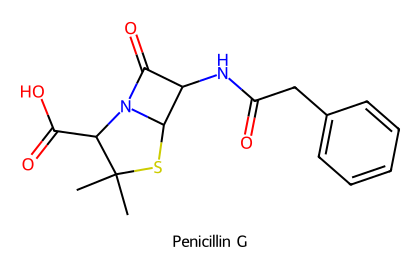

In [4]:
QUERY = "CC1(C)SC2C(NC(=O)Cc3ccccc3)C(=O)N2C1C(=O)O"
query_mol = Chem.MolFromSmiles(QUERY)

Draw.MolToImage(query_mol, size=(420, 260), legend="Penicillin G")

---
## 2. MoleculeHEALER

The three calls below map to the three stages of a run. They are separate so one
loaded building block library can serve many query molecules.

| Call | Does |
|------|------|
| `MoleculeHEALER(...)` | loads building blocks and reactions |
| `set_query_mol(...)` | fragments one query |
| `enumerate(...)` | reassembles products |

In [5]:
mol_healer = MoleculeHEALER(
    bb_source='test',       # bundled test set; use 'US_stock' or a path in practice
    reaction_tags='all',
    sim_threshold=0.0,      # relaxed: only 100 BBs to match against
    max_bbs_per_frag=10,    # keep the 10 closest BBs per fragment
    show_progress=False,
)

mol_healer.set_query_mol(QUERY, n_compositions=5, retro_tree_depth=1)
print(f"{len(mol_healer.reactions)} reaction templates loaded")

01:30:46 [INFO] Loaded 100 building blocks indexed for 82 reaction types


102 reaction templates loaded


`sim_threshold` and `max_bbs_per_frag` are alternatives. With
`max_bbs_per_frag > 0` each fragment keeps that many closest building blocks and
the threshold is ignored, which makes pool sizes and run time predictable.

### Compositions

`_process_query_mol()` runs the retrosynthesis tree. Normally `enumerate()` calls
it, but calling it directly shows how the query was cut.

2 compositions


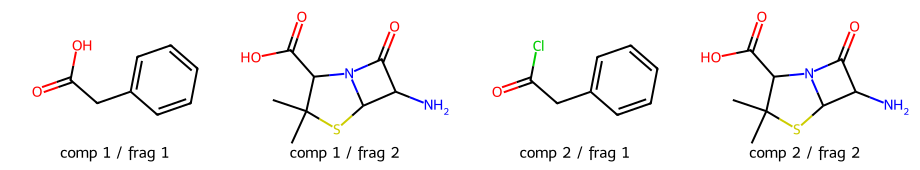

In [6]:
mol_healer._process_query_mol()

frag_mols, frag_legends = [], []
for i, comp in enumerate(mol_healer._compositions):
    for j, frag in enumerate(comp.fragments):
        frag_mols.append(frag)
        frag_legends.append(f"comp {i+1} / frag {j+1}")

print(f"{len(mol_healer._compositions)} compositions")
Draw.MolsToGridImage(frag_mols, legends=frag_legends, molsPerRow=4, subImgSize=(230, 170))

Each composition is one way of cutting the molecule. Fragments carry dummy atoms
(`*`) marking where the bond was broken; matching building blocks must be able to
form that bond again.

At `retro_tree_depth=1` the query is split in two. Depth 2 splits those halves
again for up to four fragments, at exponentially higher cost.

In [7]:
mol_healer.enumerate(max_evals_per_comp=2000, max_total_products=500)

results = mol_healer.get_results(calc_similarity=True, calc_properties=True)
print(f"{len(results)} unique products")
results.head()

01:30:46 [INFO] Enumerated 104 product(s) from 2 composition(s) in 0.1s


37 unique products


,ID,Product,BB1,BB2,Reaction1_name,URL1,URL2,Similarity_to_query,mw,logp,hba,hbd,tpsa,num_rotatable_bonds,fsp3,qed,esol_mg/L,stoplight_score,stoplight_color
0,HEAL_000000,CC1(C)SC2C(NC(=O)Cc3ccccc3)C(=O)N2C1C(=O)O,,,,,,1.00,334.397,0.86080,4,2,86.71,4,0.437500,0.797763,3940.469522,0.000000,green
1,HEAL_000001,CC(=O)N1CCC(NC(C)C(=O)N(CCc2ccccc2)Cc2ccccc2)CC1,CC(Cl)C(=O)N(CCc1ccccc1)Cc1ccccc1,CC(=O)N1CCC(N)CC1,alkylation-1,https://www.enaminestore.com/catalog/EN300-08464,https://www.enaminestore.com/catalog/EN300-13511,0.20,407.558,3.24690,3,1,52.65,8,0.440000,0.730894,29.800461,0.833333,yellow
2,HEAL_000002,CC(=O)N1CCC(NCC(=O)c2cc(C)n(CCc3ccccc3)c2C)CC1,Cc1cc(C(=O)CCl)c(C)n1CCc1ccccc1,CC(=O)N1CCC(N)CC1,alkylation-1,https://www.enaminestore.com/catalog/EN300-08261,https://www.enaminestore.com/catalog/EN300-13511,0.18,381.520,3.13084,4,1,54.34,7,0.478261,0.749937,39.954750,0.500000,yellow
3,HEAL_000003,CC(=O)N1CCC(NC(CCl)c2cc(C)n(CCc3ccccc3)c2C)CC1,Cc1cc(C(=O)CCl)c(C)n1CCc1ccccc1,CC(=O)N1CCC(N)CC1,amination-2,https://www.enaminestore.com/catalog/EN300-08261,https://www.enaminestore.com/catalog/EN300-13511,0.18,401.982,4.22804,3,1,37.27,7,0.521739,0.704748,26.502744,0.666667,yellow
4,HEAL_000004,CC(=O)N1CCC(NCc2csc(N(C(C)=O)c3ccccc3)n2)CC1,CC(=O)N(c1ccccc1)c1nc(CCl)cs1,CC(=O)N1CCC(N)CC1,alkylation-1,https://www.enaminestore.com/catalog/EN300-10187,https://www.enaminestore.com/catalog/EN300-13511,0.17,372.494,2.92820,5,1,65.54,5,0.421053,0.876383,31.158438,0.333333,yellow


Row one is the query itself, kept as a baseline with a `Similarity_to_query` of
1.001 so it sorts first. Filter it out with `results['BB1'] != ''`.

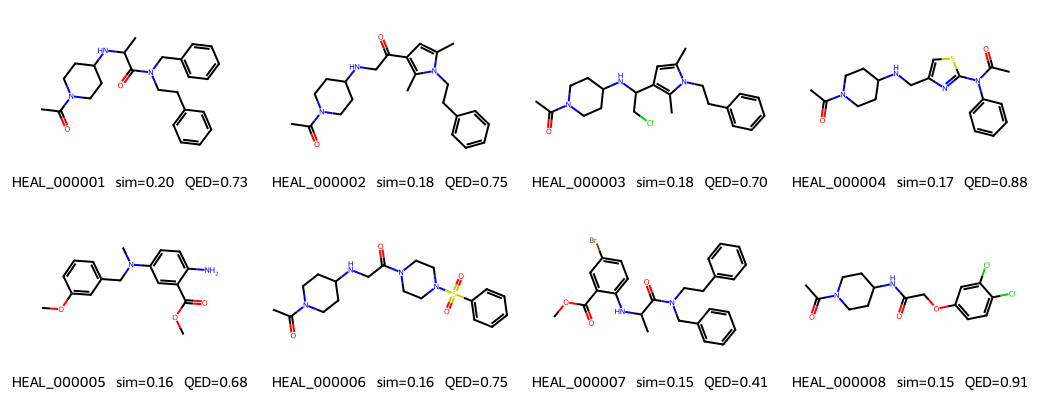

In [8]:
analogs = results[results['BB1'] != ''].reset_index(drop=True)

top = analogs.head(8)
Draw.MolsToGridImage(
    [Chem.MolFromSmiles(s) for s in top['Product']],
    legends=[f"{r.ID}  sim={r.Similarity_to_query:.2f}  QED={r.qed:.2f}"
             for r in top.itertuples()],
    molsPerRow=4,
    subImgSize=(260, 200),
)

### How the analogs sit against the query

Each product is one reaction step from purchasable material, so the useful
question is how far they move in property space while staying related to the
query.

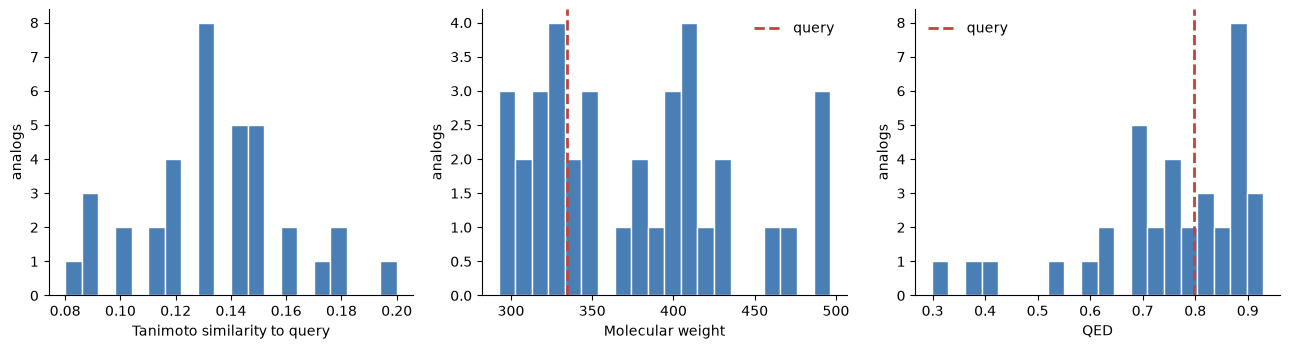

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(13, 3.6))
q = results.iloc[0]

for ax, col, label in zip(axes, ['Similarity_to_query', 'mw', 'qed'],
                          ['Tanimoto similarity to query', 'Molecular weight', 'QED']):
    ax.hist(analogs[col], bins=20, color='#4a7fb5', edgecolor='white')
    if col != 'Similarity_to_query':
        ax.axvline(q[col], color='#c1443c', ls='--', lw=2, label='query')
        ax.legend(frameon=False)
    ax.set_xlabel(label)
    ax.set_ylabel('analogs')
    ax.spines[['top', 'right']].set_visible(False)

fig.tight_layout()

---
## 3. FragmentHEALER

Skips retrosynthesis and takes the fragments you supply, as a dot-separated
SMILES or a tuple. Use it when you already know how the molecule should come
apart.

In [10]:
frag_healer = FragmentHEALER(
    bb_source='test', reaction_tags='all',
    sim_threshold=0.0, max_bbs_per_frag=10, show_progress=False,
)
frag_healer.set_query_mol('c1ccccc1N.CC(=O)O')
frag_healer.enumerate(max_total_products=200)

frag_results = frag_healer.get_results(calc_similarity=False, calc_properties=False)
print(f"{len(frag_results)} products from 2 fragments")
frag_results.head(3)

01:30:47 [INFO] Enumerated 200 product(s) from 1 composition(s) in 0.2s


131 products from 2 fragments


,ID,Product,BB1,BB2,Reaction1_name,URL1,URL2
0,HEAL_000000,CC(=O)O.Nc1ccccc1,,,,,
1,HEAL_000001,COC(=O)CNC(=O)CN(CCO)c1nc2ccccc2n1C,Cn1c(NCCO)nc2ccccc21,COC(=O)CNC(=O)CCl,alkylation-1,https://www.enaminestore.com/catalog/EN300-04785,https://www.enaminestore.com/catalog/EN300-04409
2,HEAL_000002,CC(C(=O)Nc1ccc(F)cc1)N(CCO)c1nc2ccccc2n1C,Cn1c(NCCO)nc2ccccc21,CC(Cl)C(=O)Nc1ccc(F)cc1,alkylation-1,https://www.enaminestore.com/catalog/EN300-04785,https://www.enaminestore.com/catalog/EN300-08441


---
## 4. SiteHEALER

Couples one building block onto the query at chosen atoms. There is no
fragmentation, so every product contains the intact query — this is decoration
rather than replacement.

Atom indices come first.

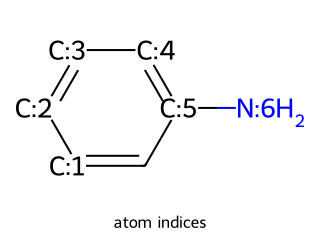

In [11]:
aniline = Chem.MolFromSmiles('c1ccccc1N')
for atom in aniline.GetAtoms():
    atom.SetAtomMapNum(atom.GetIdx())

Draw.MolToImage(aniline, size=(320, 240), legend="atom indices")

01:30:47 [INFO] Enumerated 100 product(s) from 1 composition(s) in 0.1s


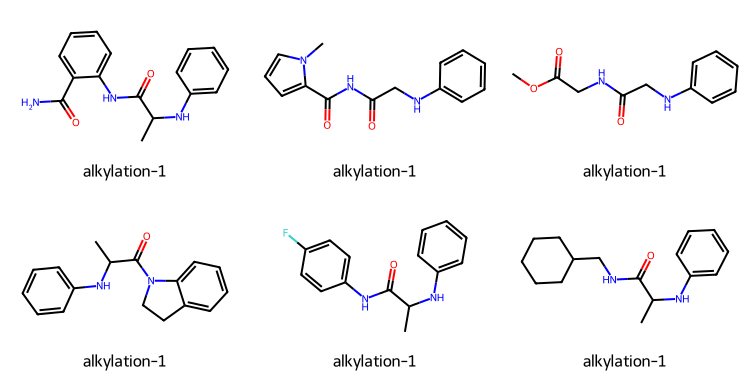

In [12]:
site_healer = SiteHEALER(
    bb_source='test',
    reaction_tags='all',
    rules={'MW': (0, 250)},     # keep added building blocks small
    show_progress=False,
)
site_healer.set_query_mol('c1ccccc1N', reactive_sites=[6])   # the nitrogen
site_healer.enumerate(max_total_products=100)

site_results = site_healer.get_results(calc_similarity=False, calc_properties=False)
site_analogs = site_results[site_results['BB1'] != ''].head(6)

Draw.MolsToGridImage(
    [Chem.MolFromSmiles(s) for s in site_analogs['Product']],
    legends=list(site_analogs['Reaction1_name']),
    molsPerRow=3, subImgSize=(250, 190),
)

`rules` filters building blocks by property, which is how product size is
controlled here: the query is always retained, so an unconstrained pool gives
increasingly heavy products. `struct_rules` additionally requires SMARTS matches.

The command line has `healer view "<smiles>"` for the same index rendering.

---
## 5. Reusing one library

Loading a real catalog dominates start-up. Repositories are cached per resolved
path, so instances sharing a `bb_source` share one copy; passing `bb_repository`
makes that explicit.

In [13]:
repo = get_repository('test')
if not repo.is_loaded:
    repo.load(show_progress=False)

shared = MoleculeHEALER(bb_repository=repo, reaction_tags='all',
                        sim_threshold=0.0, max_bbs_per_frag=5, show_progress=False)

for smi in ['CC(=O)Nc1ccccc1', 'O=C(Nc1ccccc1)c1ccccc1']:
    shared.set_query_mol(smi, n_compositions=2)
    shared.enumerate(max_total_products=50)
    print(f"{smi:24s} -> {len(shared.enumerated_molecules) - 1} products")

01:30:47 [INFO] Enumerated 50 product(s) from 2 composition(s) in 0.0s


CC(=O)Nc1ccccc1          -> 50 products


01:30:47 [INFO] Enumerated 50 product(s) from 2 composition(s) in 0.1s


O=C(Nc1ccccc1)c1ccccc1   -> 50 products


---
## 6. Guided enumeration

Exhaustive enumeration pairs every fragment with every compatible building block.
When that space is too large, an optimizer steers assembly toward a scoring
function so only a promising subset is built.

You supply the objective and **higher is always better**. Scoring is usually the
expensive step, so `batch_target_fn` is also accepted and takes priority over
`target_fn`.

Requires `pip install 'mol-healer[opt]'`.

In [14]:
def make_healer():
    return MoleculeHEALER(
        bb_repository=repo, reaction_tags='all',
        sim_threshold=0.0, max_bbs_per_frag=10, show_progress=False,
    )

def best_scores(h):
    return [r.props['optimization_score']
            for r in h.enumerated_molecules if 'optimization_score' in r.props]

objective = Crippen.MolLogP     # stand-in for a docking score or an ML model

### Beam search (stagewise)

Scores assembled intermediates at each stage and carries the best `beam_width`
forward. It scores at every stage, so keep the objective cheap.

In [15]:
h_beam = make_healer()
h_beam.set_query_mol(QUERY, n_compositions=3)
h_beam.enumerate(optimizer=BeamSearchOptimizer(beam_width=20, target_fn=objective),
                 max_total_products=300)
beam_scores = best_scores(h_beam)
print(f"beam search: {len(beam_scores)} scored, best {max(beam_scores):.2f}")

01:30:48 [INFO] Enumerated 40 product(s) from 2 composition(s) in 0.4s


beam search: 41 scored, best 6.29


### Genetic algorithm (sequence)

Proposes whole building block combinations and evolves them with PyGAD; one
ask/tell round is one generation. Genes are building block indices, one per
fragment.

In [16]:
h_ga = make_healer()
h_ga.set_query_mol(QUERY, n_compositions=3)
ga_opt = GeneticAlgorithmOptimizer(population_size=20, keep_elitism=2,
                                   random_seed=42, target_fn=objective)
h_ga.enumerate(optimizer=ga_opt, max_evals_per_comp=200, max_total_products=300)
ga_scores = best_scores(h_ga)
print(f"genetic algorithm: {len(ga_scores)} scored, best {max(ga_scores):.2f}")

01:30:48 [INFO] GeneticAlgorithmOptimizer enumerated 300 product(s) from 2 composition(s) in 0.4s


genetic algorithm: 301 scored, best 6.29


### Bayesian optimization (sequence)

BayBE with a surrogate model over MORDRED descriptors. It starts with diverse
random picks and switches to model-guided recommendations once it has
measurements — the choice when each evaluation is genuinely expensive.

BayBE enumerates the full product of the building block pools, so pools are
capped by `max_domain_per_frag`. Setting `max_bbs_per_frag` on the HEALER lets
that cap keep the *most similar* building blocks rather than an arbitrary subset.

In [17]:
h_bo = make_healer()
h_bo.set_query_mol(QUERY, n_compositions=3)
bo_opt = BayesianSequenceOptimizer(batch_size=8, target_fn=objective,
                                   max_domain_per_frag=10)
h_bo.enumerate(optimizer=bo_opt, max_evals_per_comp=48, max_total_products=300)
bo_scores = best_scores(h_bo)
print(f"bayesian optimization: {len(bo_scores)} scored, best {max(bo_scores):.2f}")

01:30:55 [INFO] BayesianSequenceOptimizer enumerated 69 product(s) from 2 composition(s) in 6.7s


bayesian optimization: 70 scored, best 6.29


### Comparing the three

With a cheap objective on 100 building blocks the differences are modest; the
point is the shape of the trade-off. Beam search scores everything it builds.
The sequence optimizers spend a fixed evaluation budget and aim to spend it well
— which is what matters when one evaluation costs minutes rather than
microseconds.

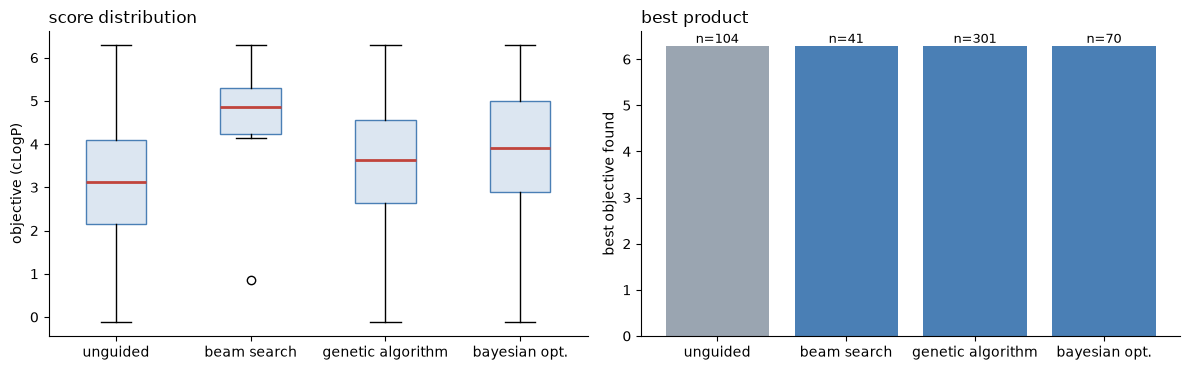

In [18]:
runs = [('unguided', None), ('beam search', beam_scores),
        ('genetic algorithm', ga_scores), ('bayesian opt.', bo_scores)]

unguided = [Crippen.MolLogP(r.product) for r in mol_healer.enumerated_molecules[1:]]
runs[0] = ('unguided', unguided)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 3.8))

ax1.boxplot([s for _, s in runs], tick_labels=[n for n, _ in runs],
            patch_artist=True,
            boxprops=dict(facecolor='#dce6f1', edgecolor='#4a7fb5'),
            medianprops=dict(color='#c1443c', lw=2))
ax1.set_ylabel('objective (cLogP)')
ax1.set_title('score distribution', loc='left')
ax1.spines[['top', 'right']].set_visible(False)

names = [n for n, _ in runs]
bests = [max(s) for _, s in runs]
counts = [len(s) for _, s in runs]
bars = ax2.bar(names, bests, color=['#9aa5b1', '#4a7fb5', '#4a7fb5', '#4a7fb5'])
for b, c in zip(bars, counts):
    ax2.text(b.get_x() + b.get_width()/2, b.get_height(), f'n={c}',
             ha='center', va='bottom', fontsize=9)
ax2.set_ylabel('best objective found')
ax2.set_title('best product', loc='left')
ax2.spines[['top', 'right']].set_visible(False)

fig.tight_layout()

### Custom optimizers

Subclass a base class to define your own. Stagewise optimizers have two hooks:
`select_candidates` runs *before* reactions are applied and receives a lazy
generator, so building-block-level heuristics prune without paying for synthesis;
`filter` runs after and sees assembled products.

In [19]:
from healer import BaseStagewiseOptimizer

class SmallBuildingBlocks(BaseStagewiseOptimizer):
    '''Reject heavy building blocks up front, then keep the best products.'''

    def __init__(self, max_heavy_atoms=15, top_k=50, **kwargs):
        super().__init__(**kwargs)
        self.max_heavy_atoms = max_heavy_atoms
        self.top_k = top_k

    def select_candidates(self, candidates, depth):
        for rec, bb, rxn in candidates:
            if bb.num_heavy_atoms <= self.max_heavy_atoms:
                yield rec, bb, rxn

    def filter(self, records, depth):
        scores = self.evaluate_batch([r.product for r in records])
        ranked = sorted(((r, s) for r, s in zip(records, scores) if s is not None),
                        key=lambda x: x[1], reverse=True)
        return [r for r, _ in ranked[:self.top_k]]

h_custom = make_healer()
h_custom.set_query_mol(QUERY, n_compositions=2)
h_custom.enumerate(optimizer=SmallBuildingBlocks(target_fn=QED.qed), max_total_products=100)

custom_results = h_custom.get_results(calc_similarity=False, calc_properties=False)
print(f"{len(custom_results) - 1} products, best QED "
      f"{max(best_scores(h_custom)):.3f}")

01:30:56 [INFO] Enumerated 100 product(s) from 2 composition(s) in 0.5s


34 products, best QED 0.933


---
## 7. Saving

`save_results()` takes the same arguments as `get_results()` and writes CSV.

In [20]:
mol_healer.save_results('penicillin_analogs.csv', calc_similarity=True, calc_properties=True)
print(list(results.columns))

['ID', 'Product', 'BB1', 'BB2', 'Reaction1_name', 'URL1', 'URL2', 'Similarity_to_query', 'mw', 'logp', 'hba', 'hbd', 'tpsa', 'num_rotatable_bonds', 'fsp3', 'qed', 'esol_mg/L', 'stoplight_score', 'stoplight_color']


For direct access to RDKit objects, `enumerated_molecules` holds the underlying
records — `product`, `bbs`, `reaction_names`, and `props`.

score      6.29
reactions  ['amination-2']
from       ['Cc1cc(C(=O)CCl)c(C)n1CCc1ccccc1', 'COC(=O)c1cc(Br)ccc1N']


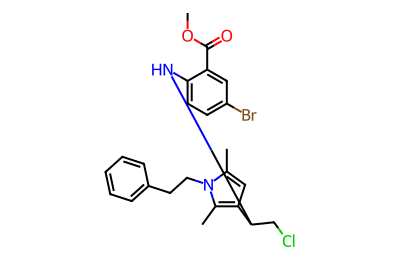

In [21]:
rec = max((r for r in h_ga.enumerated_molecules if 'optimization_score' in r.props),
          key=lambda r: r.props['optimization_score'])

print(f"score      {rec.props['optimization_score']:.2f}")
print(f"reactions  {rec.reaction_names}")
print(f"from       {[bb.get_smiles() for bb in rec.bbs]}")
Draw.MolToImage(rec.product, size=(400, 260))

---
## Where to go next

- [HEALER Classes](../docs/healer-classes.md) — every parameter of the three modes
- [Guided Enumeration](../docs/guided-enumeration.md) — optimizers in depth
- [Building Blocks](../docs/building-blocks.md) — moving from the test set to a real catalog
- [Results](../docs/results.md) — output columns and property profiling